https://www.kaggle.com/datasets/marixe/zara-sales-for-eda

# ZARA SALES


In [173]:
#include all libraries that you need
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn import metrics
import math 
from sklearn.preprocessing import LabelEncoder 

In [174]:
#Import and clean data
df = pd.read_csv('/kaggle/input/zara-sales-for-eda/Zara_sales_EDA.csv',sep=";")

In [175]:
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


In [176]:
df.columns

Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'name', 'description',
       'price', 'currency', 'terms', 'section', 'season', 'material',
       'origin'],
      dtype='object')

In [197]:
df.shape

(20250, 17)

In [178]:
df.dtypes

Product ID            int64
Product Position     object
Promotion            object
Product Category     object
Seasonal             object
Sales Volume          int64
brand                object
url                  object
name                 object
description          object
price               float64
currency             object
terms                object
section              object
season               object
material             object
origin               object
dtype: object

In [179]:
df.isna().sum()

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
name                1
description         2
price               0
currency            0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

In [180]:
df = df.dropna()
df.isna().sum()

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
name                0
description         0
price               0
currency            0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

In [181]:
df.nunique()

Product ID          20250
Product Position        3
Promotion               2
Product Category        1
Seasonal                2
Sales Volume         1284
brand                   1
url                   228
name                17215
description           221
price                 330
currency                1
terms                   5
section                 2
season                  4
material               11
origin                 12
dtype: int64

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20250 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20250 non-null  int64  
 1   Product Position  20250 non-null  object 
 2   Promotion         20250 non-null  object 
 3   Product Category  20250 non-null  object 
 4   Seasonal          20250 non-null  object 
 5   Sales Volume      20250 non-null  int64  
 6   brand             20250 non-null  object 
 7   url               20250 non-null  object 
 8   name              20250 non-null  object 
 9   description       20250 non-null  object 
 10  price             20250 non-null  float64
 11  currency          20250 non-null  object 
 12  terms             20250 non-null  object 
 13  section           20250 non-null  object 
 14  season            20250 non-null  object 
 15  material          20250 non-null  object 
 16  origin            20250 non-null  object 
dty

# Descriptive Statistics

In [183]:
df.describe()

,Product ID,Sales Volume,price
count,20250.000000,20250.000000,20250.000000
mean,208935.993383,1097.428148,41.950592
std,8949.110701,298.236187,23.381581
min,110075.000000,518.000000,12.000000
25%,204444.250000,849.000000,23.950000
50%,209506.500000,990.000000,35.950000
75%,214568.750000,1364.750000,53.950000
max,219631.000000,1940.000000,134.990000


In [199]:
# Check if promotion affects sales volume
df.groupby('Promotion')['Sales Volume'].mean()

Promotion
No      872.386452
Yes    1412.326540
Name: Sales Volume, dtype: float64


Products with promotion have (higher) average sales volume compared to non-promoted products, which suggests that promotion (increases) sales.



In [200]:
# Check correlation between price and sales
df[['price', 'Sales Volume']].corr()

,price,Sales Volume
price,1.000000,-0.337865
Sales Volume,-0.337865,1.000000



There is a (negative) correlation between price and sales volume, meaning that as price (increases), sales tend to (decreas).



In [201]:
# Get top 10 products by sales volume
df.sort_values(by='Sales Volume', ascending=False).head(10)

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
5100,204480,Front of Store,Yes,clothing,Yes,1940,Zara,https://www.zara.com/us/en/stretch-pocket-over...,TAILORED COLORBLOCK KNIT CROP SWEATER NAVY,Jacket made of cotton and linen blend fabric. ...,18.99,USD,t-shirts,WOMAN,Summer,Cotton,Portugal
8106,207486,End-cap,Yes,clothing,No,1940,Zara,https://www.zara.com/us/en/utility-pocket-jack...,SLIM BOXY FIT DENIM JACKET,Jacket made of wool blend fabric. Lapel collar...,22.95,USD,shoes,WOMAN,Winter,Polyester,Bangladesh
4581,203961,Aisle,Yes,clothing,Yes,1929,Zara,https://www.zara.com/us/en/multicolor-sneakers...,KNIT DOUBLE FACED JACKET ECRU,Round neck long sleeve sweater. Openwork detai...,19.99,USD,shoes,WOMAN,Winter,Wool,Portugal
15174,214554,Front of Store,Yes,clothing,Yes,1926,Zara,https://www.zara.com/us/en/suit-jacket-in-100-...,RELAXED ZIPPERED JACKET IVORY,Straight fit blazer made of linen. Notched lap...,22.00,USD,t-shirts,WOMAN,Summer,Linen,Spain
9982,209362,Front of Store,Yes,clothing,No,1917,Zara,https://www.zara.com/us/en/waxed-effect-plaid-...,RIBBED 100% WOOL SUIT JACKET GREY,Puffer vest made of technical fabric. Fill is ...,21.00,USD,jackets,WOMAN,Winter,Wool Blend,Turkey
3298,202678,Aisle,Yes,clothing,Yes,1912,Zara,https://www.zara.com/us/en/houndstooth-suit-ja...,OVERSIZED KNIT SWEATER WITH BUTTONS BURGUNDY,Jacket made of technical fabric with lightly p...,18.95,USD,t-shirts,WOMAN,Winter,Wool Blend,Bangladesh
5391,204771,Aisle,Yes,clothing,No,1908,Zara,https://www.zara.com/us/en/embroidered-patch-j...,RIBBED FAUX SUEDE OVERSHIRT NAVY,Full cut T-shirt with crew neck and short slee...,21.95,USD,jackets,WOMAN,Summer,Linen,Turkey
6359,205739,End-cap,Yes,clothing,Yes,1908,Zara,https://www.zara.com/us/en/cropped-bomber-jack...,SLIM PADDED BOMBER JACKET BROWN,Straight fit jeans. Five pockets. Washed effec...,25.99,USD,shoes,WOMAN,Winter,Denim,China
9663,209043,Aisle,Yes,clothing,Yes,1906,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,DOUBLE-BREASTED WOOL AND CASHMERE BLEND RIB SW...,Full cut cotton knit sweater. Round neck and l...,26.99,USD,jackets,WOMAN,Winter,Wool Blend,Morocco
944,200324,Front of Store,Yes,clothing,Yes,1899,Zara,https://www.zara.com/us/en/contrast-interior-s...,CROPPED HIGH COLLAR KNIT SWEATER ECRU,Jacket made of technical fabric with padded in...,31.00,USD,jackets,WOMAN,Winter,Wool,China


brand
Zara    20250
Name: count, dtype: int64

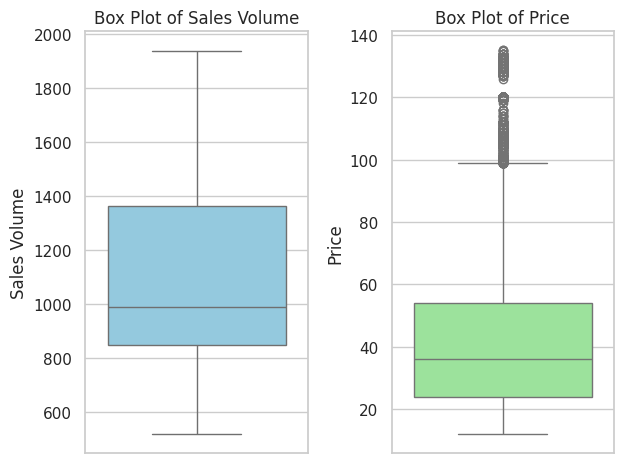

In [184]:
# Set plot style
sns.set(style="whitegrid")

# Create figure and axes
fig, axes = plt.subplots(1, 2)

# Box plot for Sales Volume
sns.boxplot(y=df['Sales Volume'], ax=axes[0], color='skyblue')
axes[0].set_title('Box Plot of Sales Volume')
axes[0].set_ylabel('Sales Volume')

# Box plot for Price
sns.boxplot(y=df['price'], ax=axes[1], color='lightgreen')
axes[1].set_title('Box Plot of Price')
axes[1].set_ylabel('Price')

# Display the plots
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

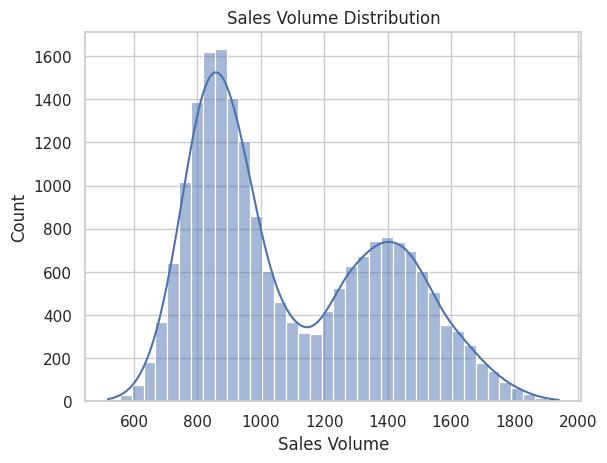

In [185]:
sns.histplot(df['Sales Volume'], kde = True)
plt.title('Sales Volume Distribution')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

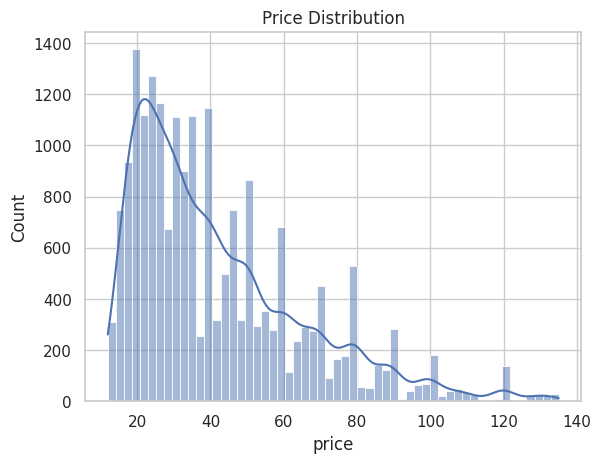

In [186]:
sns.histplot(df['price'], kde = True)
plt.title('Price Distribution')
plt.show

This indicates that most products are sold at a low price point (under $40 USD), and only a small number of products have higher prices, creating a 'long tail' to the right

# Average Sales Volume by Promotion 

In [187]:
# Promotion Impact
promo_sales = df.groupby('Promotion')['Sales Volume'].mean()
promo_lift = (promo_sales['Yes'] / promo_sales['No']) - 1
print("\nAverage Sales Volume by Promotion Status:")
print(promo_sales.to_markdown(numalign="left", stralign="left"))
print(f"Promotion Sales Lift: {promo_lift * 100:.1f}%")



Average Sales Volume by Promotion Status:
| Promotion   | Sales Volume   |
|:------------|:---------------|
| No          | 872.386        |
| Yes         | 1412.33        |
Promotion Sales Lift: 61.9%


/tmp/ipykernel_57/1335264466.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promo_sales.index, y=promo_sales.values, palette=['#1f77b4', '#ff7f0e'])


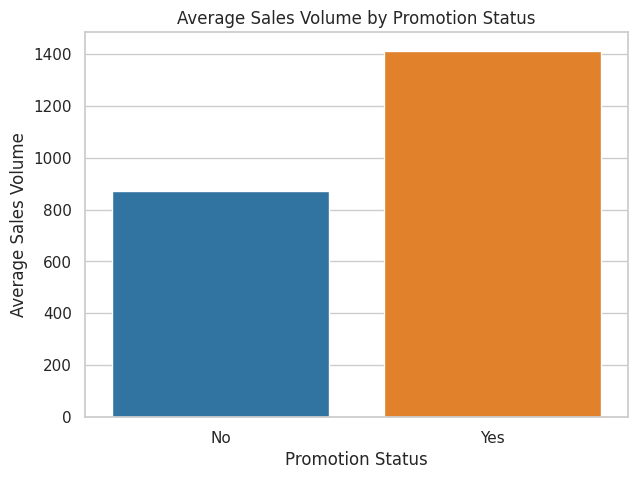

In [188]:
# Visual 1: Promotion Impact
plt.figure(figsize=(7, 5))
sns.barplot(x=promo_sales.index, y=promo_sales.values, palette=['#1f77b4', '#ff7f0e'])
plt.title('Average Sales Volume by Promotion Status')
plt.ylabel('Average Sales Volume')
plt.xlabel('Promotion Status')
plt.show()

The Power of Promotion Insight: This is the single biggest differentiator in your data.

With Promotion: Average Sales Volume = 1,412 units

Without Promotion: Average Sales Volume = 872 units

Implication: The "lift" from running a promotion is massive (~62%). This suggests that the customer base is highly deal-driven or that the promotional mechanics (visibility, perceived value) are working exceptionally well.

Key Insight: The 61.9% sales lift driven by promotion is the most significant finding. This suggests that the customer base is highly reactive to promotional cues, making promotions a strategic tool for immediate inventory clearance or revenue targets.

# Average Sales Volume by Season

In [189]:
# Seasonal Performance
print("\nAverage Sales Volume by Season:")
print(df.groupby('season')['Sales Volume'].mean().sort_values(ascending=False).to_markdown(numalign="left", stralign="left"))


Average Sales Volume by Season:
| season   | Sales Volume   |
|:---------|:---------------|
| Summer   | 1184.59        |
| Winter   | 1174.61        |
| Spring   | 1046.28        |
| Autumn   | 1042.85        |


/tmp/ipykernel_57/4036305390.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seasonal_sales.index, y=seasonal_sales.values, palette='magma')


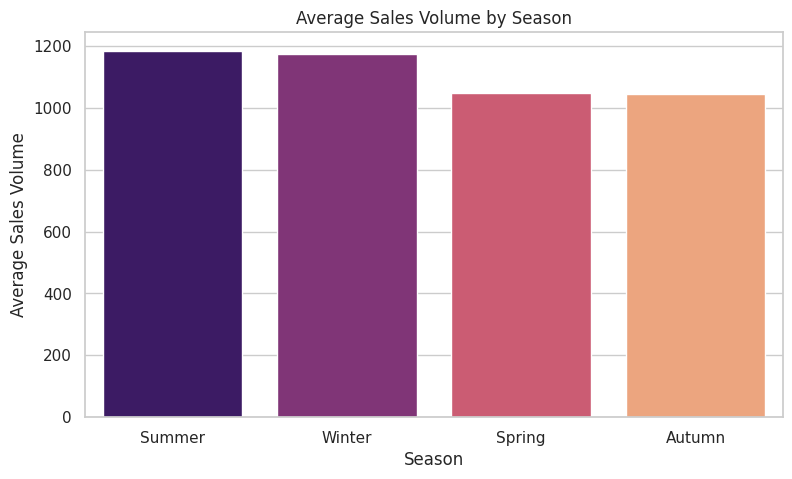

In [190]:
# Visual 2: Sales by Season
seasonal_sales = df.groupby('season')['Sales Volume'].mean().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=seasonal_sales.index, y=seasonal_sales.values, palette='magma')
plt.title('Average Sales Volume by Season')
plt.ylabel('Average Sales Volume')
plt.xlabel('Season')
plt.show()

Implication: Inventory planning should be heavily weighted towards Summer and Winter collections. The transition seasons (Spring/Autumn) are weaker and might require earlier or more aggressive promotions to clear stock.

Key Insight: Sales are heavily concentrated in the polarizing seasons (Summer and Winter), which are 13% more lucrative than the shoulder seasons (Spring and Autumn). This confirms that customers are buying heavily into dedicated seasonal categories.

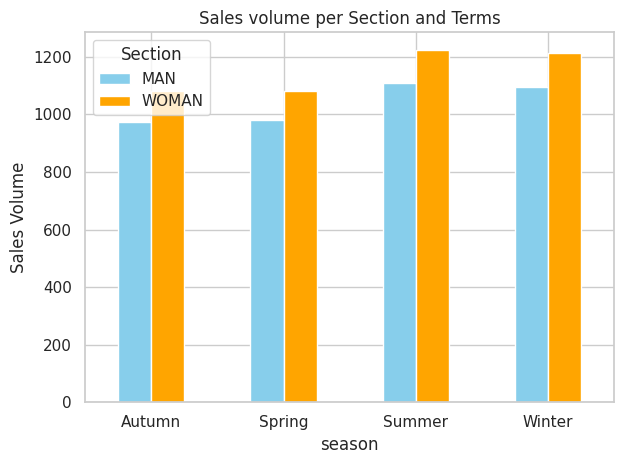

In [191]:
pivot = df.pivot_table(values='Sales Volume', index='season', columns='section')
pivot.plot(kind='bar', color=['skyblue', 'orange', 'pink', 'green', 'yellow'], title='Sales volume per Section and Terms')
plt.ylabel('Sales Volume')
plt.xlabel('season')
plt.xticks(rotation=0)
plt.legend(title='Section')
plt.tight_layout()
plt.show()

Gender & Season Dynamics
Insight: The "Summer/Winter" peak I mentioned earlier is consistent across both Men's and Women's sections, but Women's items outsell Men's items in every single season by about 100–120 units on average.

Takeaway: The seasonal trends are universal (macro-trends), but the Women's section has a higher baseline demand year-round.

# Average Sales Volume by Price Range

In [192]:
# Correlation Matrix

print("\nCorrelation between Price and Sales Volume:")
print(df[['Sales Volume', 'price']].corr())


Correlation between Price and Sales Volume:
              Sales Volume     price
Sales Volume      1.000000 -0.337865
price            -0.337865  1.000000


correlation_heatmap


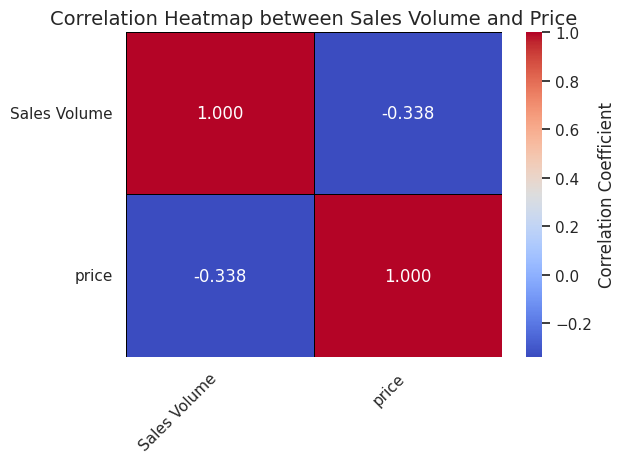

In [193]:
# Create the correlation matrix DataFrame from the provided data
corr_data = np.array([[1.000000, -0.337865],
                    [-0.337865, 1.000000]])
index_cols = ['Sales Volume', 'price']
corr_df = pd.DataFrame(corr_data, index=index_cols, columns=index_cols)

# Draw the heatmap with the correlation values annotated
sns.heatmap(corr_df, annot=True, fmt=".3f", cmap='coolwarm', linewidths=.5, linecolor='black', cbar_kws={'label': 'Correlation Coefficient'})

# Set title and adjust layout
plt.title('Correlation Heatmap between Sales Volume and Price', fontsize=14)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

print("correlation_heatmap")

Price Sensitivity 

There is a moderate negative correlation: -0.34 between price and sales. Sales volume consistently drops as the price increases.

In [194]:
# Average Sales by Origin (Top 10 sources)
top_origins = df['origin'].value_counts().nlargest(10).index
print("\nAverage Sales and Price by 'origin' (Top 10):")
print(df[df['origin'].isin(top_origins)].groupby('origin')[['Sales Volume', 'price']].mean().sort_values(by='Sales Volume', ascending=False))


Average Sales and Price by 'origin' (Top 10):
            Sales Volume      price
origin                             
Brazil       1127.154717  39.841447
China        1106.441133  41.522273
Spain        1102.843750  41.828630
Morocco      1097.758621  42.744743
India        1096.031972  42.553340
Portugal     1094.918957  42.246871
Vietnam      1094.718033  41.674369
Cambodia     1091.730612  42.048612
Turkey       1091.312727  42.501564
Bangladesh   1087.657727  42.026364


Products originating from Brazil have the lowest average price and the highest average sales. 

Implication: Zara's customers in this segment are price-conscious. Pricing strategies that keep items under the $40 threshold may see a disproportionate gain in volume.

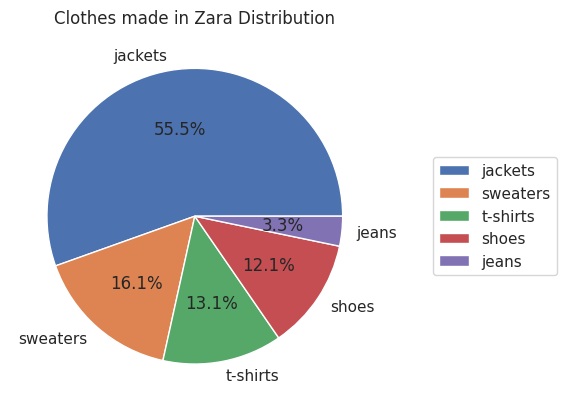

In [195]:
cloth_count = df['terms'].value_counts() 
wedges , _ , _ = plt.pie(cloth_count , labels = cloth_count.index, autopct = '%1.1f%%')
plt.title('Clothes made in Zara Distribution')
plt.legend(wedges , cloth_count.index , loc = 'right' , bbox_to_anchor = (1 , 0 , 0.5 , 1))
plt.show()

# Summary: The Formula for Success

The path to maximizing sales volume is clear: low price, high promotion, and strong seasonal relevance.
Promotion is the Single Biggest Lever: A product on promotion sells 61.9% more volume than a non-promoted product. Promotion is essential for top-tier performance.

Price Elasticity is High: There is a moderate negative correlation (p = -0.34) between price and sales. Sales volume consistently drops as the price increases.

Peak Seasons are Extreme: Summer and Winter vastly outperform Spring and Autumn, indicating a highly polarized sales cycle.